In [17]:
import numpy as np
import pandas as pd
import math
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from lightgbm import LGBMClassifier
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sklearn.model_selection import train_test_split
from category_encoders import TargetEncoder
from sklearn.ensemble import RandomForestClassifier
import warnings
from openfe import OpenFE, transform
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score
import os
from sksurv.util import Surv
warnings.filterwarnings('ignore')

### Data preprocessing

In [2]:
#Load data
train = pd.read_csv('Data/train.csv')
test = pd.read_csv('Data/test.csv')
meta = pd.read_csv('Data/metaData.csv')

#Convert to pd.Dataframe
train = pd.DataFrame(train)
test = pd.DataFrame(test)
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,0.000000,0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,0.000000,0.000000,21,5,7,44.990274,0


In [9]:
#Training data
X_train = train.drop(columns=['event', 'event_id', 'time_to_hit_hours'])
y_train = train[['time_to_hit_hours', 'event']]
y_train['event'] = y_train['event'].astype(bool)
#Testing data
X_test = test.drop(columns=['event_id'])
event_id = test['event_id']

In [11]:
y_train.head(5)

,time_to_hit_hours,event
0,18.892512,False
1,22.048108,True
2,0.888895,True
3,60.953021,False
4,44.990274,False


In [12]:
#Splitting data
X_training, X_testing, y_training, y_testing = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

### Distribution analysis

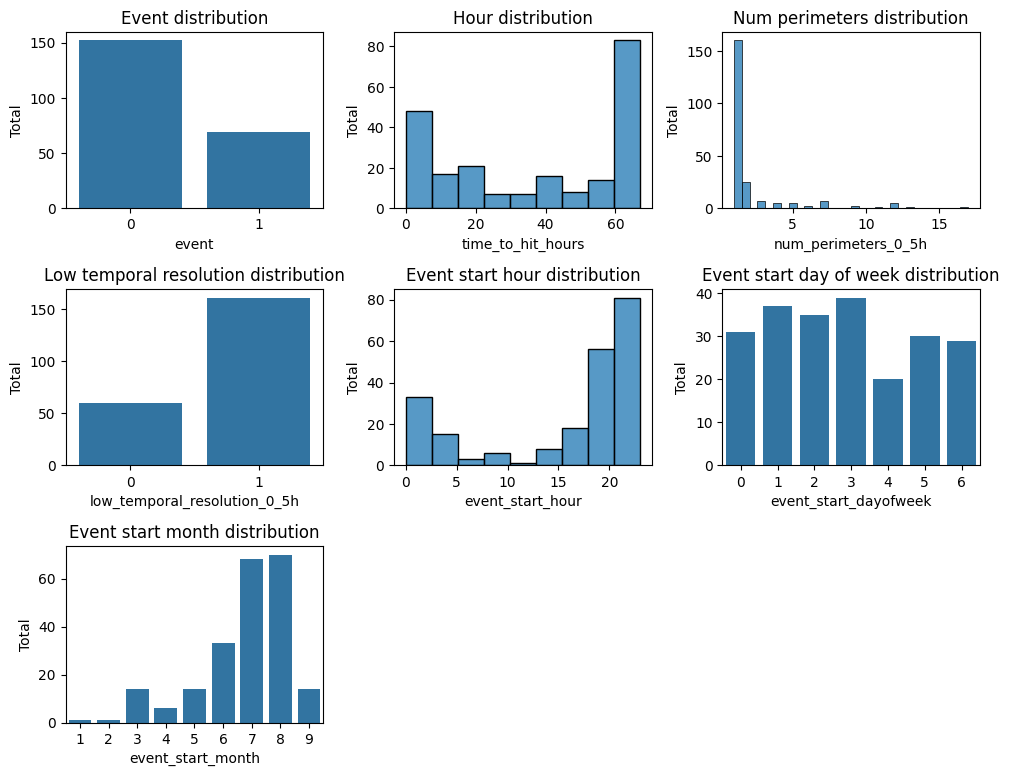

In [4]:
#Cardinality check (categorical)
fig, axes = plt.subplots(4, 3, figsize=(10, 10))
axes = axes.flatten()

sns.countplot(data=train, x='event', ax=axes[0])
axes[0].set_ylabel("Total")
axes[0].set_title('Event distribution')

sns.histplot(data=train, x='time_to_hit_hours', ax=axes[1])
axes[1].set_ylabel("Total")
axes[1].set_title('Hour distribution')

sns.histplot(data=train, x='num_perimeters_0_5h', ax=axes[2])
axes[2].set_ylabel("Total")
axes[2].set_title('Num perimeters distribution')

sns.countplot(data=train, x='low_temporal_resolution_0_5h', ax=axes[3])
axes[3].set_ylabel("Total")
axes[3].set_title('Low temporal resolution distribution')

sns.histplot(data=train, x='event_start_hour', ax=axes[4])
axes[4].set_ylabel("Total")
axes[4].set_title('Event start hour distribution')

sns.countplot(data=train, x='event_start_dayofweek', ax=axes[5])
axes[5].set_ylabel("Total")
axes[5].set_title('Event start day of week distribution')

sns.countplot(data=train, x='event_start_month', ax=axes[6])
axes[6].set_ylabel("Total")
axes[6].set_title('Event start month distribution')

for i in range(7, 12):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

### Rule base feature engineering

##### One-hot encoding

In [5]:
#One hot encoding for low_temporal_resolution_0_5h
one_hot = OneHotEncoder(
    handle_unknown='ignore',
    sparse_output=False,
    dtype=np.int8
)
one_hot.set_output(transform='pandas')

#Applying for training data
train_low_temp_transform = one_hot.fit_transform(X_train[['low_temporal_resolution_0_5h']])
X_train = pd.concat([X_train, train_low_temp_transform], axis=1).drop(columns = 'low_temporal_resolution_0_5h')
#Applying for testing data
test_low_temp_transform = one_hot.transform(X_test[['low_temporal_resolution_0_5h']])
X_test = pd.concat([X_test, test_low_temp_transform], axis=1).drop(columns = 'low_temporal_resolution_0_5h')

### Base model layer

In [22]:
gbsa = GradientBoostingSurvivalAnalysis(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=3, 
    random_state=42
)
y_train_surv = Surv.from_dataframe("event", "time_to_hit_hours", y_training)
y_test_surv = Surv.from_dataframe("event", "time_to_hit_hours", y_testing)
gbsa.fit(X_training, y_train_surv)
c_index = gbsa.score(X_testing, y_test_surv)
print(f"Concordance Index: {c_index:.4f}")

Concordance Index: 0.9337


In [35]:
surv_funcs = gbsa.predict_survival_function(X_test)
p12 = [1 - sf(min(12, sf.x[-1])) for sf in surv_funcs]
p24 = [1 - sf(min(24, sf.x[-1])) for sf in surv_funcs]
p48 = [1 - sf(min(48, sf.x[-1])) for sf in surv_funcs]
p72 = [1 - sf(min(72, sf.x[-1])) for sf in surv_funcs]

In [ ]:
submission = {
    'event_id' : event_id,
    'prob_12h' : p12,
    'prob_24h' : p24,
    'prob_48h' : p48,
    'prob_72h' : p72
}
submission = pd.DataFrame(submission)
#submission.to_csv('result.csv', index=False)

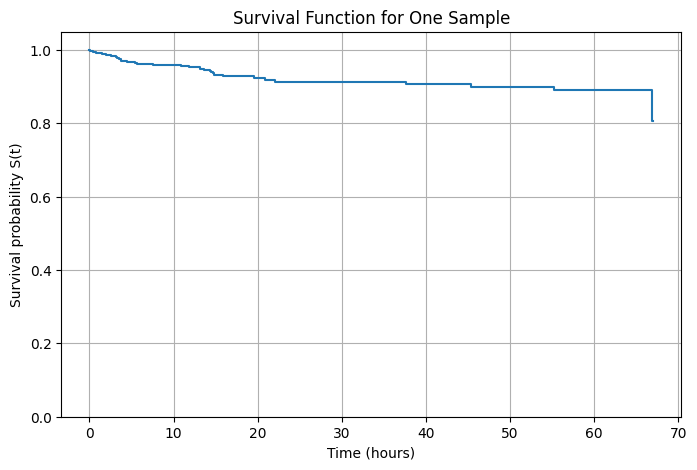

In [41]:
sf = surv_funcs[0]

# Plot it
plt.figure(figsize=(8, 5))
plt.step(sf.x, sf.y, where="post")
plt.xlabel("Time (hours)")
plt.ylabel("Survival probability S(t)")
plt.title("Survival Function for One Sample")
plt.ylim(0, 1.05)
plt.grid(True)
plt.show()

##### Target Encoding

In [55]:
category_col = [
    'event_start_hour',
    'event_start_dayofweek',
    'event_start_month'
]

### Feature engineering
Automated feature engineering

### Scaling

### Feature Selection

### OOF prediction

### Meta-Learner

### Prediction

### Evaluation metric
$$Hybrid\ Score = 0.3 \times \text{C-index} + 0.7 \times (1 - \text{Weighted Brier Score})$$

### Final Prediction

In [42]:
file_path = "result.csv"
os.remove(file_path)

In [56]:
def oof_target_encode(X_train, y_train, X_test, cat_cols, n_splits):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    X_train_enc = X_train.copy()
    X_test_enc = X_test.copy()
    #test-set encoded values from each categorical column
    test_preds = np.zeros((len(X_test), len(cat_cols)))

    X_train_enc[cat_cols] = X_train_enc[cat_cols].astype(float)
    X_test_enc[cat_cols] = X_test_enc[cat_cols].astype(float)

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
        enc = TargetEncoder(cols=cat_cols, smoothing=10)
        enc.fit(X_train.iloc[train_idx][cat_cols], y_train.iloc[train_idx])
        X_train_enc.loc[X_train.index[val_idx], cat_cols] = enc.transform(
            X_train.iloc[val_idx][cat_cols]
        ).values
        test_preds += enc.transform(X_test[cat_cols]).values / n_splits
    
    X_test_enc[cat_cols] = test_preds
    return X_train_enc, X_test_enc

#Target encoding for training and testing data
#X_train, X_test = oof_target_encode(X_train, y_train, X_test, category_col, n_splits=5)